In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
import copy

SEED = 42

features = ["pitch_entropy","rhythmic_entropy","average_interval_size","average_vertical_density","average_polyphonic_voices","fractal_dimension","num_notes","pitch_std","pitch_range","number_of_instruments","unique_note_values","average_beat_gap","most_common_note","average_note_length","largest_leap","orch_outer_voice_motion_index","orch_harmonic_change_entropy","orch_global_npvi"]

torch.manual_seed(SEED)

df = pd.read_csv('train_data.csv')

X_raw = torch.tensor(df[features].to_numpy())
Y_raw = torch.tensor(df["composer_label"].to_numpy())
print(np.unique(df["composer_label"].to_numpy()))

print(X_raw.shape, Y_raw.shape)

X_train, X_test, Y_train, Y_test = train_test_split(X_raw, Y_raw, test_size=0.2, random_state=SEED, stratify=Y_raw)
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.1, random_state=SEED, stratify=Y_train)

print(X_train.shape, X_val.shape, X_test.shape)

scaler = StandardScaler()
X_train = torch.tensor(scaler.fit_transform(X_train), dtype=torch.float32)
X_val = torch.tensor(scaler.transform(X_val), dtype=torch.float32)
X_test = torch.tensor(scaler.transform(X_test), dtype=torch.float32)

[0 1 2 3 4 5 6 7 8 9]
torch.Size([320, 18]) torch.Size([320])
torch.Size([230, 18]) torch.Size([26, 18]) torch.Size([64, 18])


In [2]:
train_dataset = TensorDataset(X_train, Y_train) 
val_dataset = TensorDataset(X_val, Y_val)
test_dataset = TensorDataset(X_test, Y_test)

batch_size = 230
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [3]:
# class ComposerClassifier(nn.Module): 
#     def __init__(self, input_dimension, hidden_dimension, output_dimension): 
#         super().__init__()
#         self.network = nn.Sequential(
#             nn.Linear(input_dimension, hidden_dimension), 
#             nn.ReLU(), 
#             nn.Linear(hidden_dimension, hidden_dimension-2),
#             nn.ReLU(), 
#             # nn.Linear(hidden_dimension-2, hidden_dimension-2), 
#             # nn.Sigmoid(), 
#             nn.Linear(hidden_dimension-2, output_dimension)
#         )
        
#     def forward(self, x): 
#         return self.network(x)

In [4]:
class ComposerClassifier(nn.Module): 
    def __init__(self, input_dimension, hidden_dimension, output_dimension, dropout_rate=0.01): 
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dimension, hidden_dimension), 
            nn.ReLU(), 
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_dimension, hidden_dimension-2),
            nn.ReLU(), 
            nn.Linear(hidden_dimension-2, hidden_dimension-2), 
            nn.Sigmoid(), 
            nn.Linear(hidden_dimension-2, output_dimension)
        )
        
    def forward(self, x): 
        return self.network(x)

    def predict_with_mc_entropy(self, x, num_samples=30):
        self.eval()
        for module in self.modules():
            if isinstance(module, nn.Dropout):
                module.train()

        # Collection tensor for sampled probabilities: shape (num_samples, batch_size, output_dimension)
        mc_probs = []

        with torch.no_grad():
            for _ in range(num_samples):
                logits = self.forward(x)
                probs = F.softmax(logits, dim=-1)
                mc_probs.append(probs)

        # Stack along a new dimension: (num_samples, batch_size, output_dim)
        mc_probs = torch.stack(mc_probs, dim=0)

        # 1. Calculate average predicted probabilities across MC samples: (batch_size, output_dim)
        mean_probs = torch.mean(mc_probs, dim=0)

        # 2. Compute Predictive Entropy: - sum(p * log(p)) over class dimension
        # Adding 1e-12 inside log prevents log(0) numerical instability
        entropy = -torch.sum(mean_probs * torch.log(mean_probs + 1e-12), dim=-1)

        return mean_probs, entropy

In [5]:
model = ComposerClassifier(X_train.shape[1], 14, len(np.unique(Y_raw)))

criterion = nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

In [6]:
print("Training started")


NUM_EPOCHS = 1000
PATIENCE = 20
patience_counter = 0
best_val_loss = float("inf")
best_mode_weights = None

loss_history = []
accuracy_history = []

for epoch in range(NUM_EPOCHS): 
    model.train() 
    train_loss = 0
    accuracy = 0
    
    for batch_X, batch_Y in train_loader:     
        optimizer.zero_grad()
        pred = model(batch_X)
        loss = criterion(pred, batch_Y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()*batch_X.size(0)
        train_pred = pred.argmax(dim=1)
        accuracy += (train_pred == batch_Y).sum().item()
        
    avg_loss = train_loss / len(train_loader.dataset)
    avg_acc = accuracy / len(train_loader.dataset)*100
    
    # ----------- Validation ----------- #
    model.eval()
    val_loss = 0
    val_acc = 0
    with torch.no_grad(): 
        for batch_X, batch_Y in val_loader: 
            pred = model(batch_X)
            loss = criterion(pred, batch_Y)
            
            val_loss += loss.item()*batch_X.size(0)
            val_pred = pred.argmax(dim=1)
            val_acc += (val_pred == batch_Y).sum().item()
            
        avg_loss_val = val_loss / len(val_loader.dataset)
        avg_acc_val = val_acc / len(val_loader.dataset)
        
    scheduler.step(avg_loss_val)
    
    if avg_loss_val < best_val_loss: 
        best_val_loss = avg_loss_val
        best_mode_weights = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else: 
        patience_counter += 1
    if patience_counter >= PATIENCE: 
        print("Early Stopping...")
        break
        
    loss_history.append(avg_loss)
    accuracy_history.append(avg_acc)
    print(f"Epoch {epoch} \t Train Loss: {avg_loss:.4f} \t Train Accuracy: {avg_acc:.4f} \t Val Loss: {avg_loss_val:.4f} \t Val Accuracy: {avg_acc_val:.4f}")

Training started
Epoch 0 	 Train Loss: 2.3476 	 Train Accuracy: 2.6087 	 Val Loss: 2.3370 	 Val Accuracy: 0.0385
Epoch 1 	 Train Loss: 2.3401 	 Train Accuracy: 2.6087 	 Val Loss: 2.3296 	 Val Accuracy: 0.0385
Epoch 2 	 Train Loss: 2.3326 	 Train Accuracy: 2.6087 	 Val Loss: 2.3221 	 Val Accuracy: 0.0385
Epoch 3 	 Train Loss: 2.3253 	 Train Accuracy: 2.6087 	 Val Loss: 2.3147 	 Val Accuracy: 0.0385
Epoch 4 	 Train Loss: 2.3180 	 Train Accuracy: 2.6087 	 Val Loss: 2.3074 	 Val Accuracy: 0.0385
Epoch 5 	 Train Loss: 2.3108 	 Train Accuracy: 2.6087 	 Val Loss: 2.3000 	 Val Accuracy: 0.0385
Epoch 6 	 Train Loss: 2.3037 	 Train Accuracy: 2.6087 	 Val Loss: 2.2927 	 Val Accuracy: 0.0385
Epoch 7 	 Train Loss: 2.2964 	 Train Accuracy: 2.6087 	 Val Loss: 2.2855 	 Val Accuracy: 0.0385
Epoch 8 	 Train Loss: 2.2893 	 Train Accuracy: 2.6087 	 Val Loss: 2.2782 	 Val Accuracy: 0.0385
Epoch 9 	 Train Loss: 2.2824 	 Train Accuracy: 2.6087 	 Val Loss: 2.2711 	 Val Accuracy: 0.0385
Epoch 10 	 Train Loss: 

[2.3476107120513916, 2.3400509357452393, 2.3326480388641357, 2.3253273963928223, 2.318042039871216, 2.310826301574707, 2.3036530017852783, 2.2964351177215576, 2.289348840713501, 2.28243088722229, 2.2753067016601562, 2.2684738636016846, 2.2616586685180664, 2.254741668701172, 2.2479512691497803, 2.241101026535034, 2.234402894973755, 2.22778058052063, 2.221081256866455, 2.2142930030822754, 2.207746982574463, 2.2013254165649414, 2.1948206424713135, 2.1881744861602783, 2.1817312240600586, 2.175403118133545, 2.168996810913086, 2.1625092029571533, 2.156386613845825, 2.1498587131500244, 2.143493175506592, 2.1372275352478027, 2.131126642227173, 2.125173568725586, 2.1184029579162598, 2.1124768257141113, 2.106492042541504, 2.1006102561950684, 2.0942132472991943, 2.088510513305664, 2.0821022987365723, 2.076246500015259, 2.070556402206421, 2.064298629760742, 2.058464765548706, 2.0523366928100586, 2.046828508377075, 2.0409018993377686, 2.0348057746887207, 2.028934955596924, 2.0231454372406006, 2.017

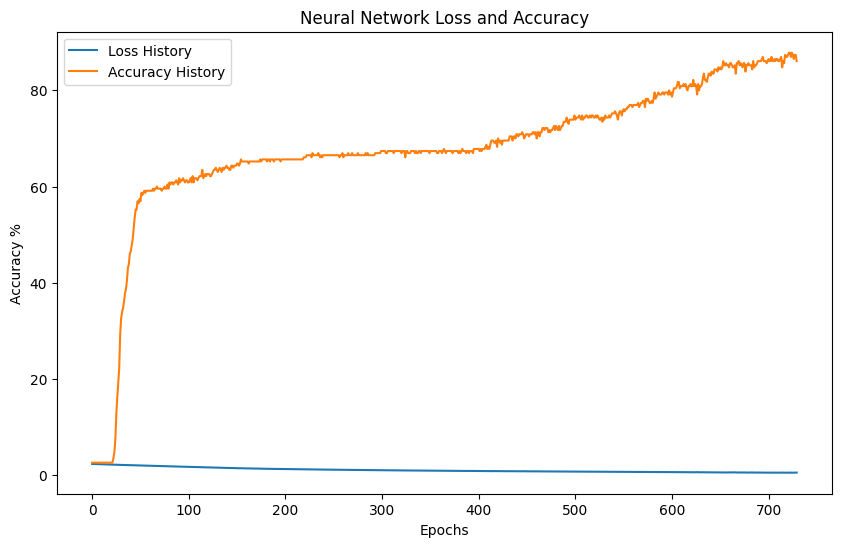

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
print(loss_history)
plt.plot(loss_history, label="Loss History")
plt.plot(accuracy_history, label="Accuracy History")
plt.title("Neural Network Loss and Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy %")
plt.legend()
plt.show()

In [8]:
# model.eval()
# all_preds = []
# all_targets = []
# with torch.no_grad():
#     for batch_X, batch_Y in test_loader:
#         pred = model(batch_X)

#         test_pred = pred.argmax(dim=1)
#         all_preds.extend(test_pred.cpu().numpy())
#         all_targets.extend(batch_Y.cpu().numpy())
        
# target_names = np.unique(df["composer"].to_numpy())
# print(classification_report(all_targets, all_preds, target_names=target_names))

[0.7190798  0.8746     0.40870976 0.61363953 0.62542385 0.721702
 0.77126276 0.7621907  0.3313518  1.0628489  0.98329407 0.41925937
 0.8043056  0.70534587 0.27902177 0.3055523  0.30278036 0.5821527 ]


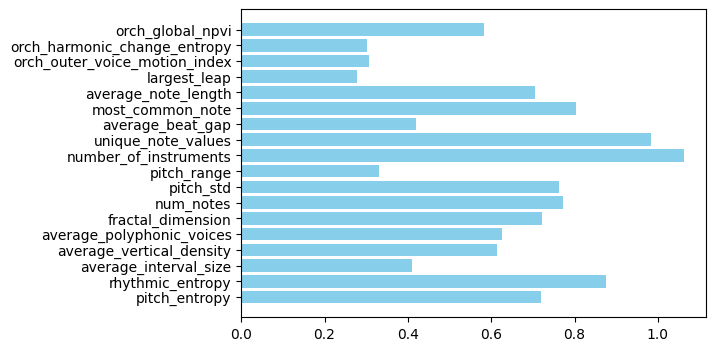

In [9]:
# --- Feature Importance via Input Gradient Analysis ---
X_test_grad = X_test.clone().detach().requires_grad_(True)

output = model(X_test_grad)
output.sum().backward()

importance = X_test_grad.grad.abs().mean(dim=0).numpy()
print(importance)
feature_names = features

plt.figure(figsize=(6, 4))
plt.barh(feature_names, importance, color="skyblue")
plt.show()

[tensor([0.4646, 0.7377, 1.8318, 0.5668, 0.8662, 1.8965, 0.7168, 0.8511, 1.0137,
        0.5290, 0.5347, 0.4918, 0.7561, 1.6683, 0.9029, 1.2811, 0.5543, 0.5459,
        2.0145, 0.7202, 2.0180, 0.4640, 0.4677, 0.5103, 0.5932, 0.4938, 1.0876,
        0.6385, 0.6237, 0.5301, 0.6908, 0.8303, 0.5568, 1.5819, 0.5118, 0.8907,
        1.1231, 0.6980, 0.6257, 1.7114, 0.5666, 0.6167, 0.5491, 0.5081, 0.5909,
        0.8301, 0.5597, 0.5745, 0.9485, 1.8965, 0.5237, 0.5309, 0.5998, 0.8971,
        0.5135, 1.5656, 0.5792, 0.6781, 1.3253, 1.1854, 0.5257, 0.6027, 0.4699,
        0.8426, 0.4711, 0.8380, 0.6721, 0.6302, 0.8571, 1.8247, 0.5092, 0.5340,
        0.6320, 0.4700, 0.9195, 0.6402, 0.4638, 1.4869, 2.0225, 1.8960, 0.6487,
        0.6757, 1.0611, 0.6622, 0.9473, 0.6913, 0.4889, 0.7329, 0.6044, 0.5338,
        0.8837, 0.9094, 0.9588, 1.8966, 1.4356, 1.9148, 1.8703, 0.6898, 0.5739,
        0.4898, 0.5539, 0.8583, 0.9771, 0.4644, 2.0198, 0.9886, 0.7930, 0.5920,
        0.5130, 1.0330, 0.5791, 1.5879,

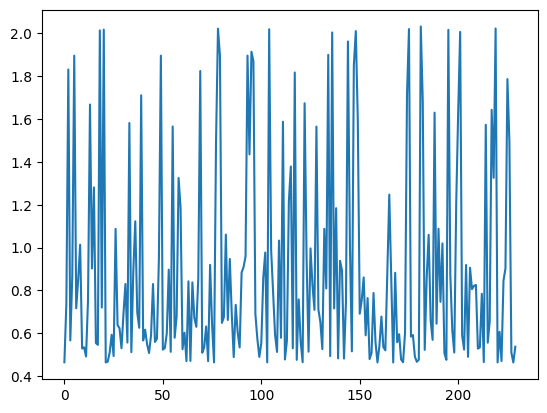

In [10]:
all_entropies = []

for batch_X, batch_Y in train_loader: 
    mean_probs, entropy = model.predict_with_mc_entropy(batch_X)
    all_entropies.append(entropy)
    
print(all_entropies, all_entropies[0].mean())
plt.plot(all_entropies[0])
plt.show()

In [18]:
test_10 = pd.read_csv("test_data_composers.csv")
test_10_X = test_10[features].to_numpy()
test_10_X = torch.tensor(scaler.fit_transform(test_10_X), dtype=torch.float32)
test_10_Y = test_10["composer"].to_numpy()

model.eval()

all_preds = []
all_targets = [] 

with torch.no_grad():
    pred = model(test_10_X)
    
    test_pred = pred.argmax(dim=1)
    all_preds.extend(test_pred.cpu().numpy())
    # all_targets.extend(test_10_Y.cpu().numpy())
    
print(all_preds)

composer_to_label = {
    "Bach": 0, 
    "Beethoven": 1, 
    "Brahms": 2, 
    "Cambini": 3, 
    "Dvorak": 4, 
    "Faure": 5, 
    "Haydn": 6, 
    "Mozart": 7, 
    "Ravel": 8, 
    "Schubert": 9
}

labels = []

for label in test_10_Y: 
    labels.append(composer_to_label[label])
    
print(labels)
print(test_10_Y)
    
# target_names = np.unique(df["composer"].to_numpy())
# print(classification_report(all_targets, all_preds, target_names=target_names))

# model.eval()
# all_preds = []
# all_targets = []
# with torch.no_grad():
#     for batch_X, batch_Y in test_loader:
#         pred = model(batch_X)

#         test_pred = pred.argmax(dim=1)
#         all_preds.extend(test_pred.cpu().numpy())
#         all_targets.extend(batch_Y.cpu().numpy())
        
# target_names = np.unique(df["composer"].to_numpy())
# print(classification_report(all_targets, all_preds, target_names=target_names))


[0, 2, 2, 1, 1, 0, 2, 0, 1, 9]
[0, 6, 1, 1, 1, 0, 7, 0, 1, 9]
['Bach' 'Haydn' 'Beethoven' 'Beethoven' 'Beethoven' 'Bach' 'Mozart' 'Bach'
 'Beethoven' 'Schubert']
